### Worksheet 4: Discover the Higgs Boson!

#### Original work statement: 

Please write your name here to indicate that your worksheet is the result of your own work, and you have not copied from sources without citing them (this is plagiarism and is not acceptable). Identical or very similar worksheet will share the credit.

#### Your name: Se Rang Seo (Simon)

For this worksheet, we provide you with a (simplified) version of the simulated Higgs boson data challenge, run by Kaggle in 2014. The files are called "Higgs_features.csv" and "Higgs_labels.csv". The labels are 0 and 1, corresponding to "no Higgs signal", and "Higgs signal".

In [128]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rc
from sklearn.svm import SVC, LinearSVC # New algorithm!
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_predict, cross_validate
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn import metrics
from sklearn.model_selection import GridSearchCV # New! This will be used to explore different hyperparameter choices.
import seaborn as sns
import sklearn
from sklearn.pipeline import make_pipeline #This allows one to build different steps together
from sklearn.tree import DecisionTreeClassifier #how methods are imported 
from sklearn import neighbors # here comes the method of the day
from sklearn.svm import SVC, LinearSVC # New algorithm!
from sklearn.utils import shuffle

In [94]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder() #turns categorical into 1 ... N

In [108]:
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    plt.figure(figsize=(7,6))
    print(cm)
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center", verticalalignment="center",
                 color="C2" if i == j else "C3", fontsize = 30)

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

1\. Read the data into two numpy arrays or data frames, one for features and one for labels.

In [95]:
features0 = pd.read_csv('Higgs_features.csv')
labels0 = pd.read_csv('Higgs_labels.csv')

In [96]:
features0.head()

,393.3350,79.4600,308.8790,4.0950,1.4030,-1.4110,49.0630,39.4780
0,71.048,29.291,55.602,2.439,1.667,-1.412,22.926,9.486
1,141.450,87.017,72.091,1.472,4.714,1.233,23.591,69.754
2,156.539,39.797,127.933,4.017,1.279,-1.408,21.415,18.222
3,89.639,34.399,66.741,2.934,1.417,-1.377,26.459,8.257
4,103.203,7.979,56.074,1.420,0.476,1.216,57.804,60.140


In [97]:
features0['393.3350']

0         71.048
1        141.450
2        156.539
3         89.639
4        103.203
          ...   
24994    109.449
24995    139.483
24996     78.421
24997     90.507
24998   -999.000
Name: 393.3350, Length: 24999, dtype: float64

In [98]:
labels0.head()

,0
0,0
1,0
2,0
3,0
4,0


In [99]:
labels0['0']

0        0
1        0
2        0
3        0
4        0
        ..
24994    0
24995    1
24996    0
24997    0
24998    0
Name: 0, Length: 24999, dtype: int64

2\. How many instances and features are in this data set?

### <span style="color: lightblue">Response:
There are 8 features (columns) and there are 24999 instances (rows).
Labels have 1 feature for: '0'.<span>

3\. Plot the distribution of each feature for this data set in a histogram (like we did in on of the previous worksheets), in one plot. Add a legend (with labels "Feature 1", "Feature 2"...) and set the transparency of the histograms (property "alpha") to 0.5 for clarity. Hint: make sure you are plotting each column, not each row!

Text(0, 0.5, '$N$')

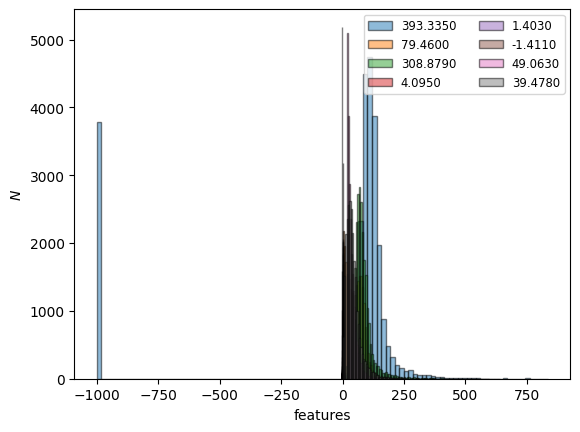

In [100]:
fig1 = plt.figure()
for i in range(len(features0.columns)):
    plt.hist(features0.iloc[:,i], bins = 100, alpha = 0.5, label=features0.columns[i], edgecolor='black')

legend = plt.legend(loc='upper right', fontsize='small', ncol=2)

plt.xlabel("features")
plt.ylabel('$N$')

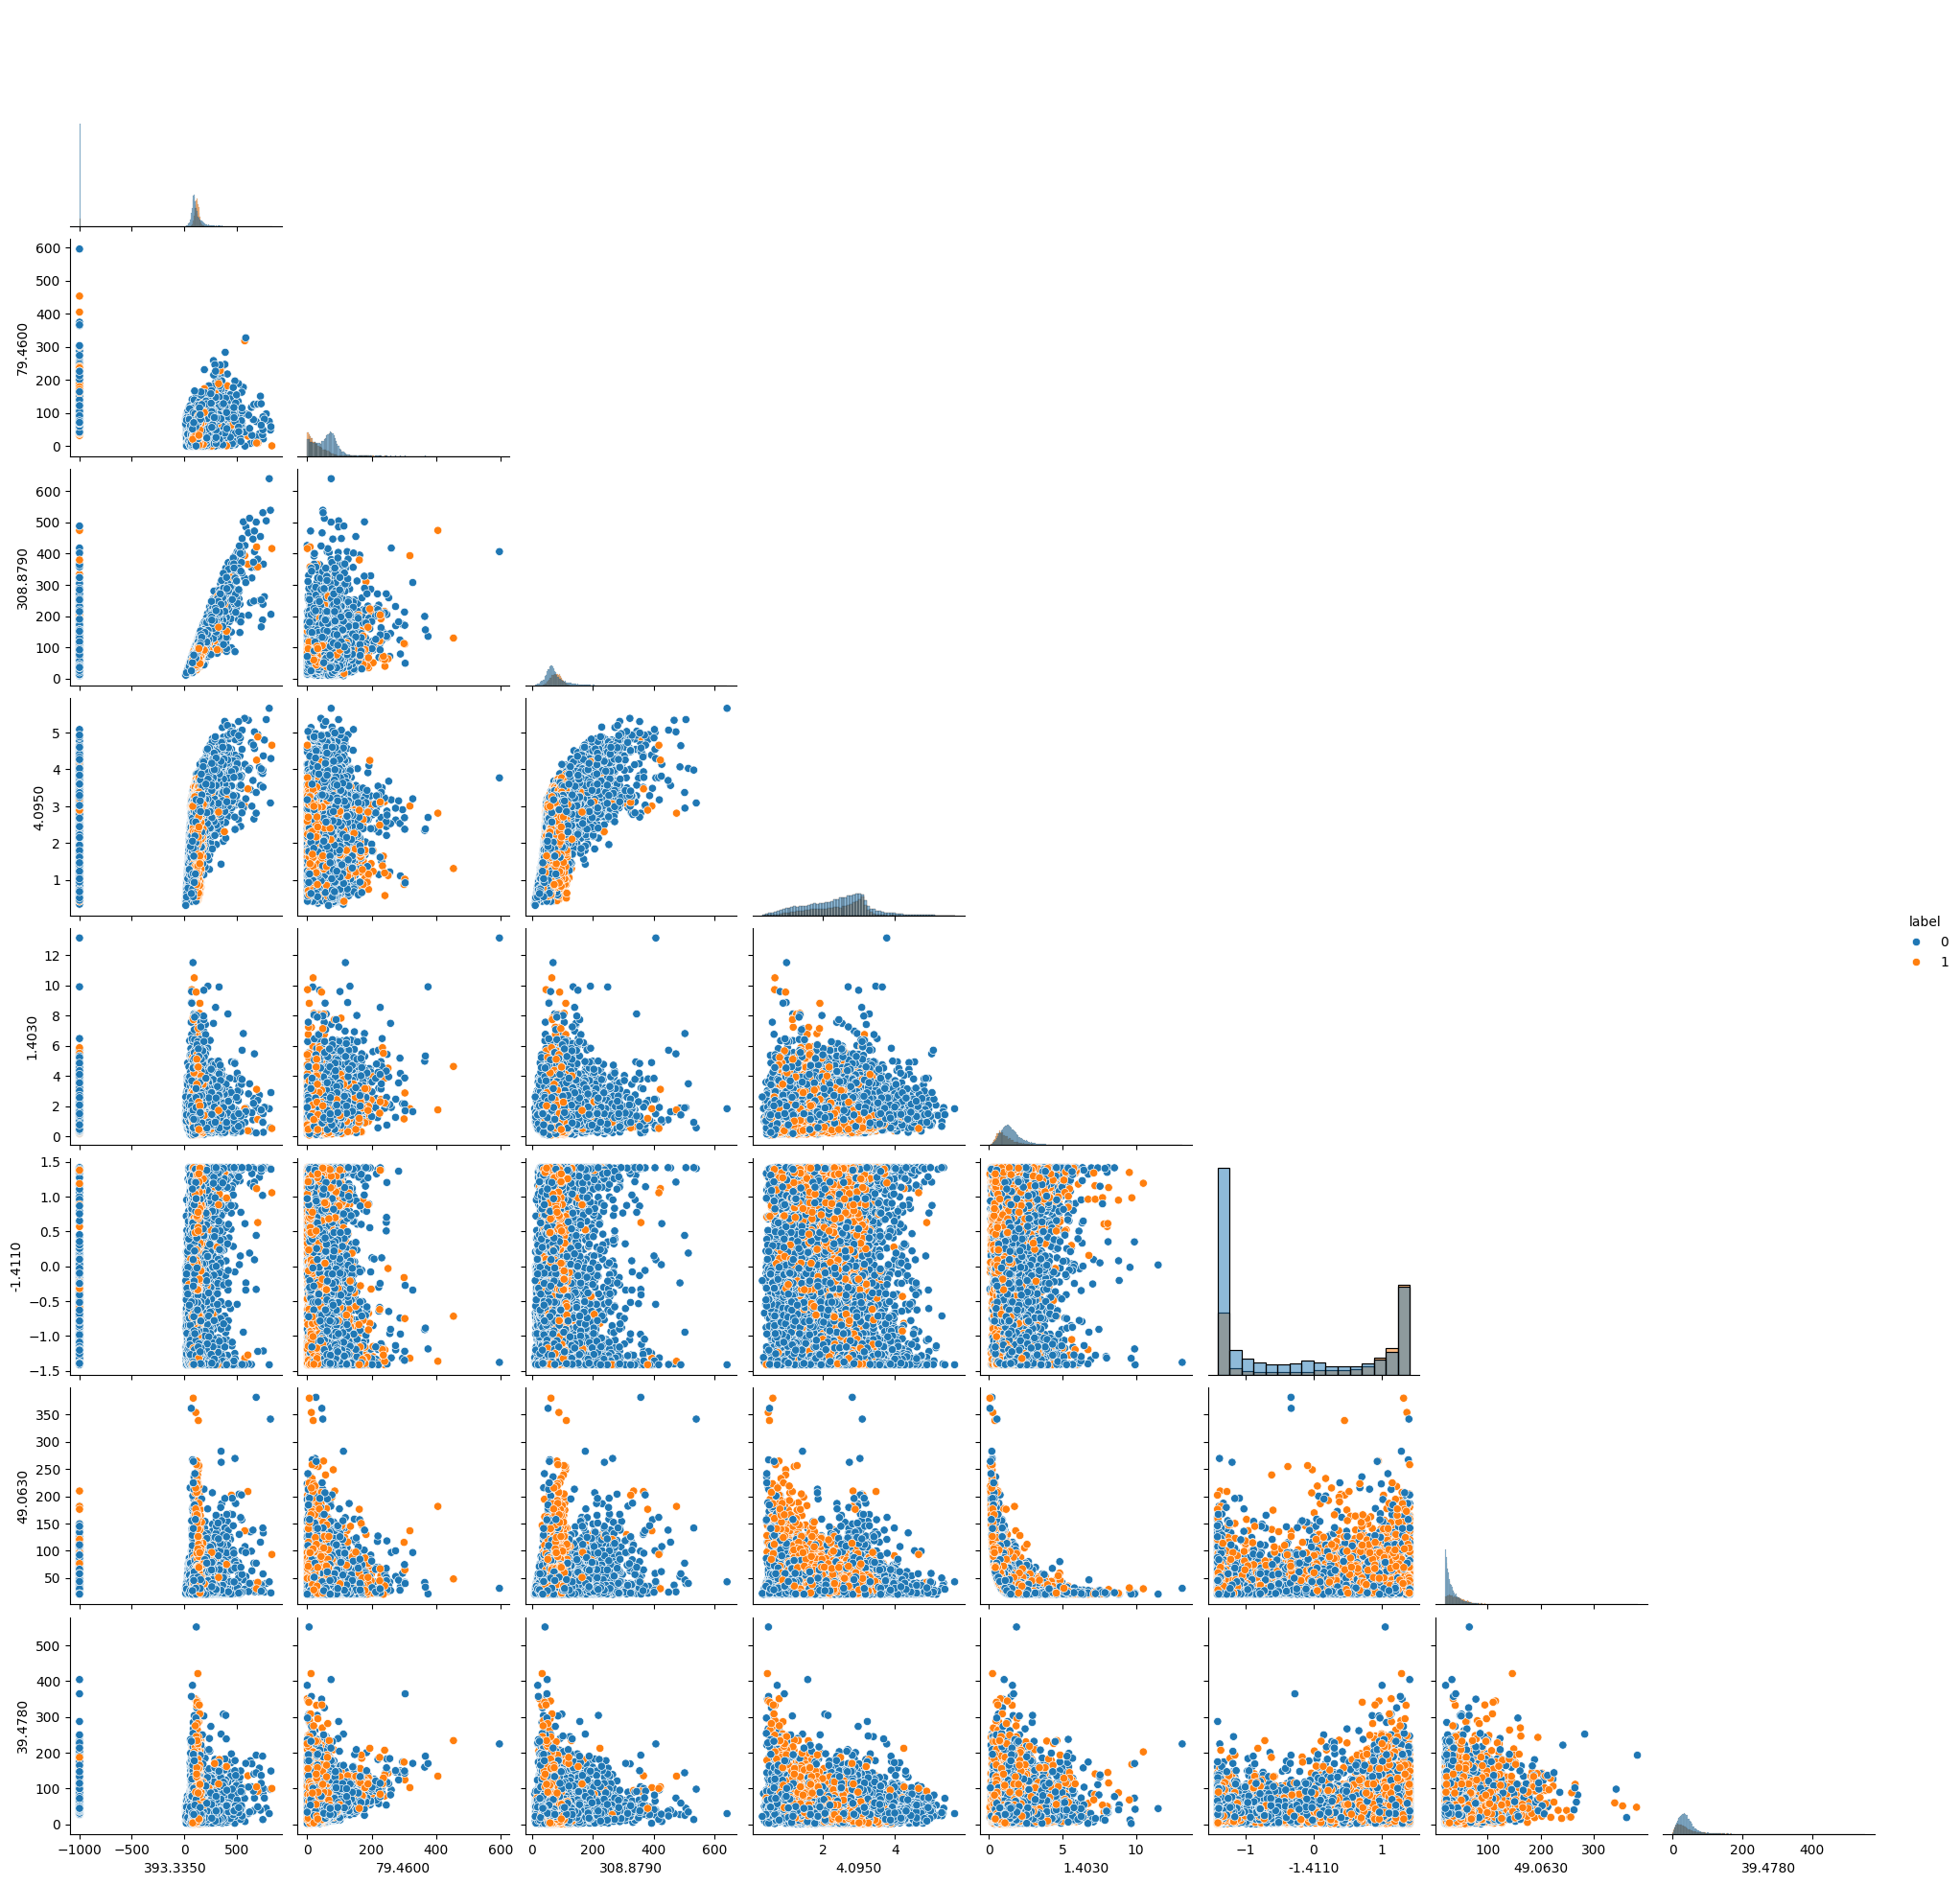

In [101]:
features1 = features0.copy()
features1['label'] = labels0.iloc[:, 0]

# Create colored pair plot
sns.pairplot(features1, corner=True, hue='label', diag_kind='hist')
plt.show()

4\. Do you see anything unusual in the distribution of any of the features? What problem could this cause?


### <span style="color: lightblue">Response:
1. There are spaces in between -1000 and 0 at 393.3350.
2. Box scatter at 4.0950 and -1.4110 (middle).
3. There are curves at 1.4030 and 49.0630
4. Some linear scatter at 393.3350 and 308.8790.
5. The reason can be due to outliers.
<span>

5\. How many positive (Higgs) events does your data set contain? Based on this, is the data set balanced or unbalanced?

In [102]:
ones = labels0[labels0.iloc[:, 0] == 1]
zeros = labels0[labels0.iloc[:, 0] == 0]
print("Number of 1's: ", len(ones))
print("Number of 0's: ", len(zeros))

Number of 1's:  8474
Number of 0's:  16525


### <span style="color: lightblue">Response:
Bases on the number of 1's and 0's, the dataset is unbalanced. 
<span>

6\. On the basis of your answer to 5, which evaluation metric (accuracy, precision, recall) would you like to pick for this data set?

### <span style="color: lightblue">Response:
We don't want to look into accuracy because the dataset is unbalanced and the result will be falsely successful.
We want to use precision (how many right did we get right and how many wrong did we get wrong correctly) or recall (missing analysis or completeness).
<span>

7\. Use a decision tree classifier as your model, and do five fold cross validation on your data, <b> using the scoring parameter you chose above</b>. Report the mean and standard deviation of the scores obtained for the five folds.

Note: If you simply set the parameter "cv = 5" in the cross_val_score function, this will divide the data in five sets using the first 20%, second 20%... etc of your data, which is not great if your data are in a specific order. Make sure you use cv = StratifiedKFold(shuffle=True, n_splits=5).


In [103]:
targets = labels0.iloc[:, 0]

In [ ]:
dt = DecisionTreeClassifier()
cv = StratifiedKFold(n_splits=5, shuffle=True)

benchmark = cross_validate(dt, features0, targets, cv = cv, scoring = 'precision', return_train_score=True)

In [105]:
benchmark

{'fit_time': array([0.14993286, 0.14718986, 0.151371  , 0.1592586 , 0.14999223]),
 'score_time': array([0.00283122, 0.00265408, 0.00304294, 0.00306511, 0.00260425]),
 'test_score': array([0.63319302, 0.62769784, 0.63769818, 0.62176166, 0.63059919]),
 'train_score': array([1., 1., 1., 1., 1.])}

The precision is 63%.

8\. We want to now take a look at the confusion matrix for your classifier. Generate the predicted label using the "cross_val_predict" function, then print the confusion matrix.

Confusion matrix, without normalization
[[13387  3138]
 [ 3027  5447]]


<Figure size 640x480 with 0 Axes>

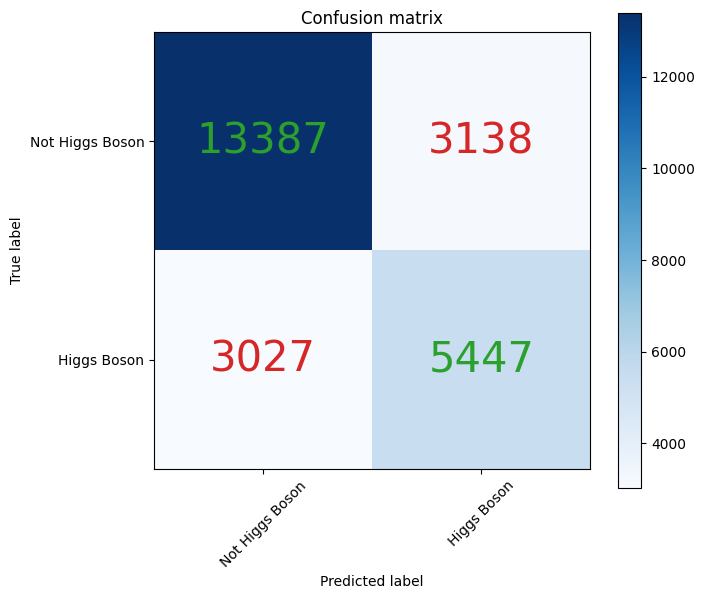

In [111]:
y_pred = cross_val_predict(dt, features0, targets, cv = cv)
cm = metrics.confusion_matrix(targets,y_pred)
fig6 = plt.figure()
plot_confusion_matrix(cm, ['Not Higgs Boson','Higgs Boson'])

9\. Given your confusion matrix, how many true positives / true negatives / false positives / false negatives are there? Do you have more type I errors (false positives) than type II errors (false negatives)?

### <span style="color: lightblue">Response:
Trues are the diagonal. False are the other diagonal. Negative is first column. Positive is second column.

[TN: 13432] [FP: 3093]

[FN: 2977]   [TP: 5397]

Type I Error: FP = 3093
Type II Error: FN = 2977

There are more Type I Errors than Type II.
<span>

10\. Let's now switch to a SVC classifier. Leaving the parameters of the classifier at their default values, run a five-fold cross validation and report the scores just like you did above for the decision tree. (Note: SVMs are slow so this might take some time, a good 5 minutes on my laptop. If it takes too long, you can reduce the number of folds to 3). Which algorithm performs better? 

In [113]:
svc = SVC()

benchmark = cross_validate(svc, features0, targets, cv = cv, scoring = 'precision', return_train_score=True)
benchmark

{'fit_time': array([4.12474418, 4.05324435, 4.35714889, 4.26991034, 4.15460515]),
 'score_time': array([1.98223591, 1.97914696, 2.09018445, 2.10001898, 2.10087109]),
 'test_score': array([0.7162726 , 0.73467916, 0.74148714, 0.7291372 , 0.71211073]),
 'train_score': array([0.72877193, 0.72589099, 0.72148122, 0.72890295, 0.73142756])}

The precision is 71%.

The result is 8% better than Decision Tree Classifer's.

11\. Report the confusion matrix for the SVC algorithm. Do you notice a change in the distribution of the false positives and false negatives, with respect to the decision tree algorithm?

Confusion matrix, without normalization
[[14571  1954]
 [ 3316  5158]]


<Figure size 640x480 with 0 Axes>

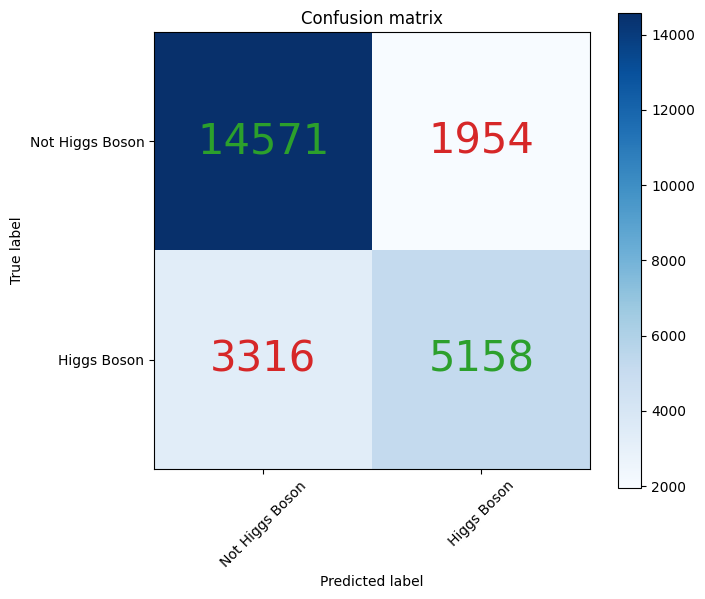

In [114]:
y_pred = cross_val_predict(svc, features0, targets, cv = cv)
cm = metrics.confusion_matrix(targets,y_pred)
fig6 = plt.figure()
plot_confusion_matrix(cm, ['Not Higgs Boson','Higgs Boson'])

### <span style="color: lightblue">Response:
Trues are the diagonal. False are the other diagonal. Negative is first column. Positive is second column.

[TN: 14571] [FP: 1954]

[FN: 3316]   [TP: 5158]

Type I Error: FP = 1954
Type II Error: FN = 5158

There are more Type II Errors than Type I.

There are much more FN than that of Decision Tree's.
<span>

12\. We can now try to optimize the parameters of the SVC. Because it would otherwise take a long time, we can select the first 5% of the data set (after shuffling the data set). 

You can do it using the code below, but you need to change the original array names for features and targets to match yours. You will then produce the two arrays "Xlittle, ylittle".

In [ ]:
ftrs, trgt = shuffle(features0, targets, random_state = 13)

number_samples = ftrs.shape[0]

Xlittle, ylittle = ftrs[:int(number_samples*0.05)], trgt[:int(number_samples*0.05)]

Xlittle.shape #check that everything went as expected

(1249, 8)

13\. Set up and run a GridSearch CV with the following parameters: 

parameters = {'kernel':['linear','rbf'],'C':[1, 10, 100], 'gamma':[0.01, 0.1, 0.5], 'class_weight':[{1:1},{1:3},{1:5}]}

You can use the code from the particle ID with SVMs notebook, but remember to change the scoring parameter to match what you did above.

Note: this might take time! Set verbose = 2 in the GridSearchCV to follow the progress, and set njobs = 4 or more to speed up the process. 

#### Report the scores and parameters values of the best model.

In [133]:
parameters = {'kernel': ['linear','rbf'],'C':[1,10,100], 'gamma':[0.01,0.1,0.5],'class_weight':[{1:1},{1:3},{1:5}]}

model = GridSearchCV(svc, parameters, cv = cv, verbose = 2, n_jobs = 4, return_train_score=True)

model.fit(Xlittle,ylittle)

print('Best params, best score:', "{:.4f}".format(model.best_score_), model.best_params_)

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best params, best score: 0.7270 {'C': 10, 'class_weight': {1: 1}, 'gamma': 0.01, 'kernel': 'linear'}


14\. Based on what you found, would you recommend to use a Decision Tree Classifier or a Support Vector Classifier for this problem?

### <span style="color: lightblue">Response:
The best precision was 72% using optimal parameters of SVC which isn't very high..
So, I would try using decision tree and see what the optimal parameters are and what their results would be.
<span>

Extra Credit: The object GridSearchCV (probably called clf or model in your code) that you created above has an attribute "cv\_results\_" that allows you to visualize the scores for every combination of parameters; we did it in the SVM notebook. Based on this, which parameter has the highest impact (induces the largest change) on the performance of the SVC? Do you think it might be worth optimizing it further?

I couldn't see the full list of params column, so I got this.

In [137]:
pd.set_option('display.max_colwidth', None)  # Show full content in columns
pd.set_option('display.max_columns', None)   # Show all columns
pd.set_option('display.width', None)         # Auto-detect display width
pd.set_option('display.max_rows', None)      # Show all rows (optional)

In [136]:
scores_lim = pd.DataFrame(model.cv_results_)
scores_lim.columns
scores_lim[['params','mean_test_score','std_test_score','mean_train_score', \
            'mean_fit_time']].sort_values(by = 'mean_test_score', ascending = False)

,params,mean_test_score,std_test_score,mean_train_score,mean_fit_time
20,"{'C': 10, 'class_weight': {1: 1}, 'gamma': 0.1, 'kernel': 'linear'}",0.726991,0.020489,0.733589,42.884164
18,"{'C': 10, 'class_weight': {1: 1}, 'gamma': 0.01, 'kernel': 'linear'}",0.726991,0.020489,0.733589,37.742292
22,"{'C': 10, 'class_weight': {1: 1}, 'gamma': 0.5, 'kernel': 'linear'}",0.726991,0.020489,0.733589,41.479226
4,"{'C': 1, 'class_weight': {1: 1}, 'gamma': 0.5, 'kernel': 'linear'}",0.726194,0.017617,0.734189,4.444436
0,"{'C': 1, 'class_weight': {1: 1}, 'gamma': 0.01, 'kernel': 'linear'}",0.726194,0.017617,0.734189,4.479501
2,"{'C': 1, 'class_weight': {1: 1}, 'gamma': 0.1, 'kernel': 'linear'}",0.726194,0.017617,0.734189,4.469552
38,"{'C': 100, 'class_weight': {1: 1}, 'gamma': 0.1, 'kernel': 'linear'}",0.724594,0.024422,0.728186,103.714343
40,"{'C': 100, 'class_weight': {1: 1}, 'gamma': 0.5, 'kernel': 'linear'}",0.724594,0.024422,0.728186,119.450578
36,"{'C': 100, 'class_weight': {1: 1}, 'gamma': 0.01, 'kernel': 'linear'}",0.724594,0.024422,0.728186,97.737036
1,"{'C': 1, 'class_weight': {1: 1}, 'gamma': 0.01, 'kernel': 'rbf'}",0.718175,0.009640,0.954164,0.024352


1	{'C': 1, 'class_weight': {1: 1}, 'gamma': 0.01...	0.718175	0.009640	0.954164	0.0243521	{'C': 1, 'class_weight': {1: 1}, 'gamma': 0.01...	0.718175	0.009640	0.954164	0.024352

There are some that jump from 0.01 order to 0.001 order standard deviation test scores.

But within C, 10, 1:1 weight range, they're all similar, so I would try a different classifier.

I also notice that 'rbf' kernel reduces the std the most, so I might explore that a bit more. But linear provides the best precision, so I can try varying that more.